###ML Experiment 9 - Predict Customer Churn

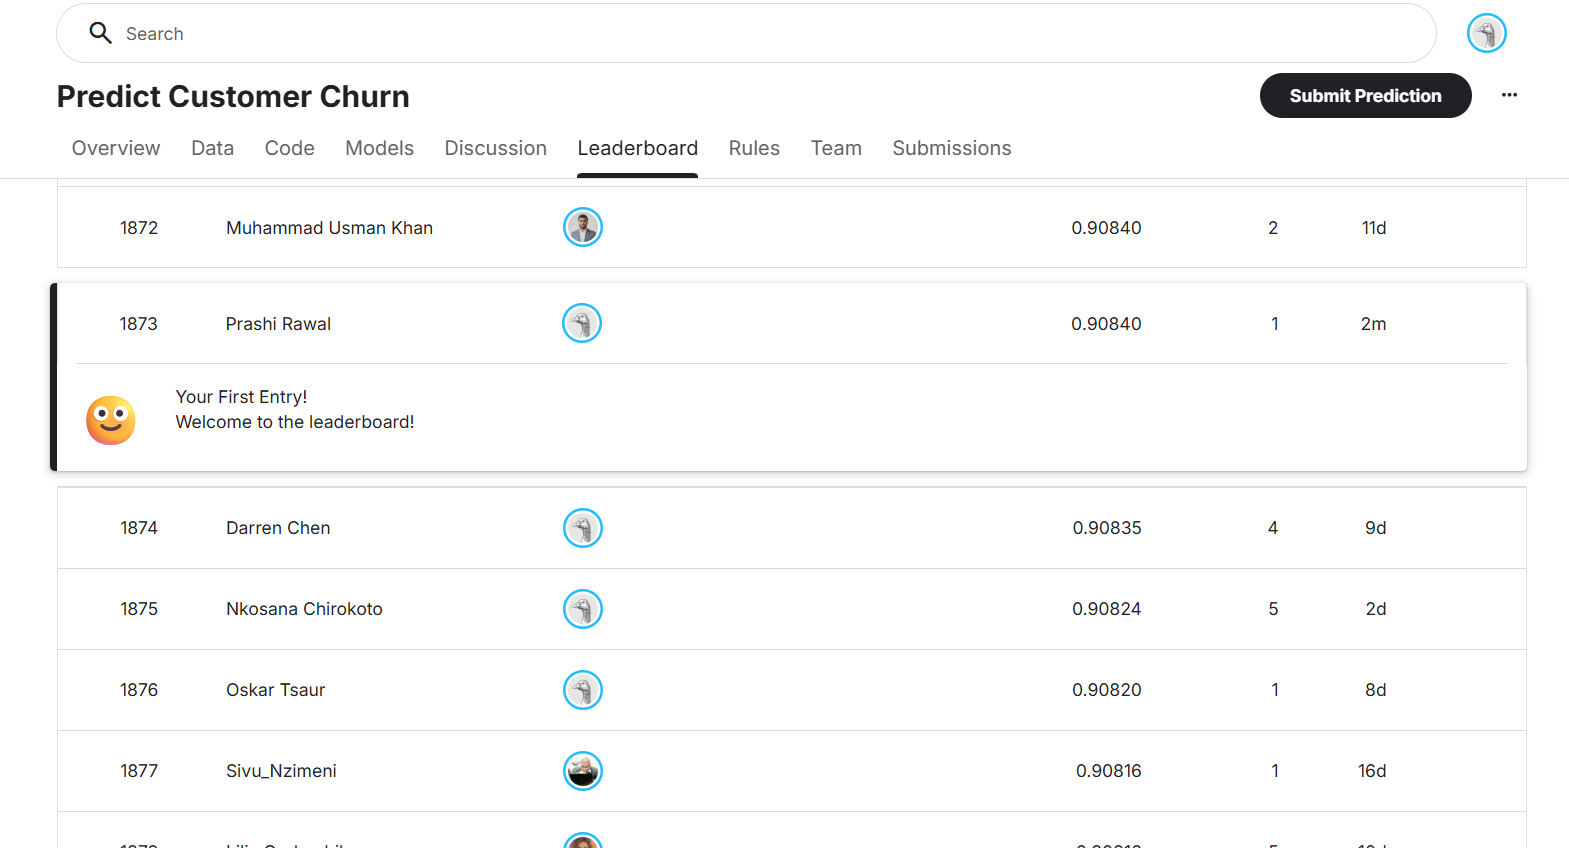

[Github Link](https://github.com/PRASHIRAWAL/ML-LAB-PROBLEM-STATEMENT-/tree/main/Problem%20Statement%208)

In [ ]:
!pip install catboost
!pip install optuna

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import optuna

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.4 MB/s eta 0:00:00


In [ ]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [ ]:
train['Churn'] = train['Churn'].map({'Yes':1,'No':0})
original = pd.read_csv('/content/train.csv')
original = original.drop('id',axis = 1)
original['Churn'] = original['Churn'].map({'No': 0, 'Yes': 1})
train = pd.concat([train, original], axis=0).reset_index(drop=True)

In [ ]:
print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")
train.head()

Train Shape: (1188388, 22)
Test Shape: (254655, 21)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalServicesCount,AvgCostPerMonth
0,1,0,1,1,29,1,0,0,2,0,...,0,0,1,1,3,60.10,1653.85,NaN,4,55.128333
1,1,0,1,1,58,1,0,0,2,2,...,2,0,2,0,1,69.50,3778.20,NaN,5,64.037288
2,1,0,1,0,58,1,2,1,0,2,...,2,2,0,1,2,100.40,5841.35,NaN,5,99.005932
3,0,0,0,0,1,1,0,1,0,0,...,0,0,0,1,2,69.70,70.70,NaN,1,35.350000
4,0,0,0,0,1,1,0,1,0,0,...,0,0,0,1,2,70.45,70.45,NaN,1,35.225000


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1188388 entries, 0 to 1188387
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   gender            1188388 non-null  object 
 1   SeniorCitizen     1188388 non-null  int64  
 2   Partner           1188388 non-null  object 
 3   Dependents        1188388 non-null  object 
 4   tenure            1188388 non-null  int64  
 5   PhoneService      1188388 non-null  object 
 6   MultipleLines     1188388 non-null  object 
 7   InternetService   1188388 non-null  object 
 8   OnlineSecurity    1188388 non-null  object 
 9   OnlineBackup      1188388 non-null  object 
 10  DeviceProtection  1188388 non-null  object 
 11  TechSupport       1188388 non-null  object 
 12  StreamingTV       1188388 non-null  object 
 13  StreamingMovies   1188388 non-null  object 
 14  Contract          1188388 non-null  object 
 15  PaperlessBilling  1188388 non-null  object 
 16  

In [ ]:
train.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
train['TotalCharges'] = pd.to_numeric(train['TotalCharges'], errors='coerce').fillna(0)
test['TotalCharges'] = pd.to_numeric(test['TotalCharges'], errors='coerce').fillna(0)

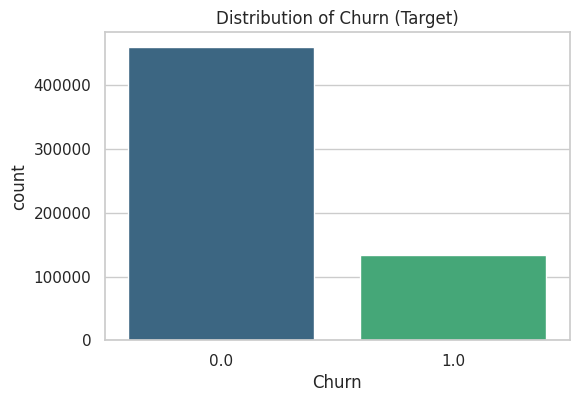

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=train, palette='viridis')
plt.title('Distribution of Churn (Target)')
plt.show()

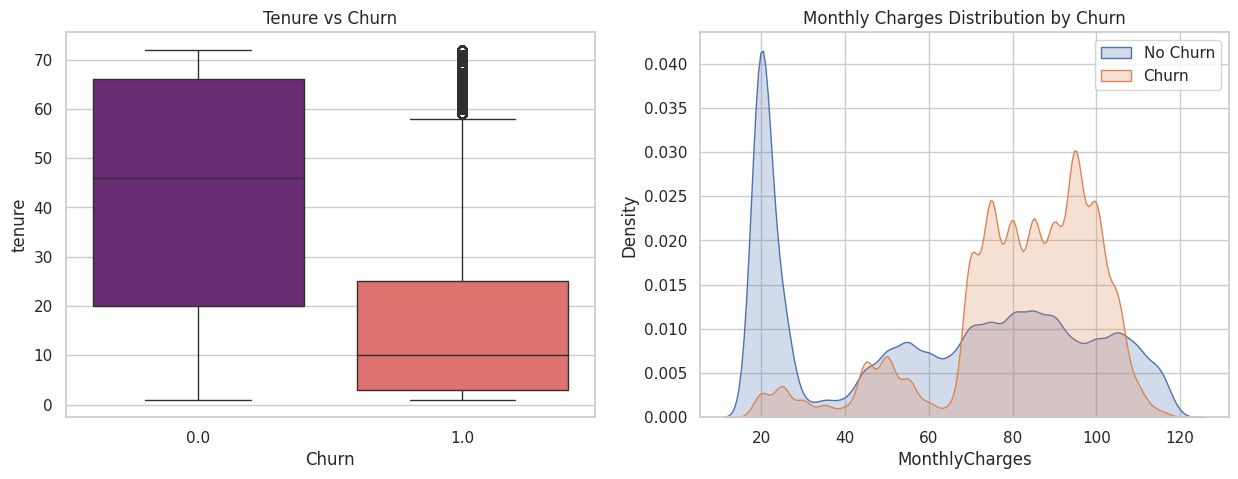

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x='Churn', y='tenure', data=train, ax=axes[0], palette='magma')
axes[0].set_title('Tenure vs Churn')

sns.kdeplot(train[train['Churn'] == 0]['MonthlyCharges'], shade=True, label='No Churn', ax=axes[1])
sns.kdeplot(train[train['Churn'] == 1]['MonthlyCharges'], shade=True, label='Churn', ax=axes[1])
axes[1].set_title('Monthly Charges Distribution by Churn')

plt.legend()
plt.show()

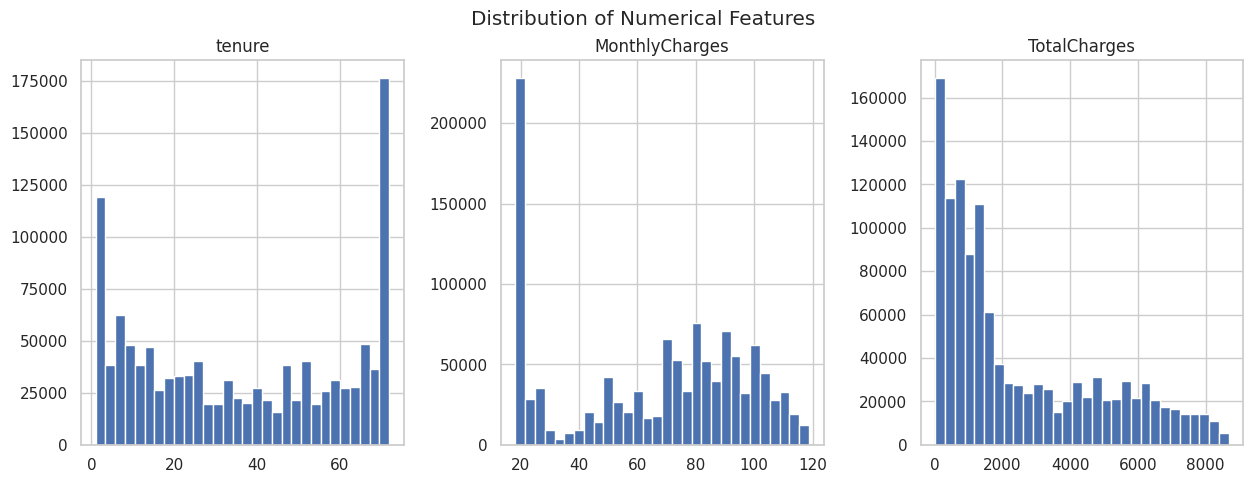

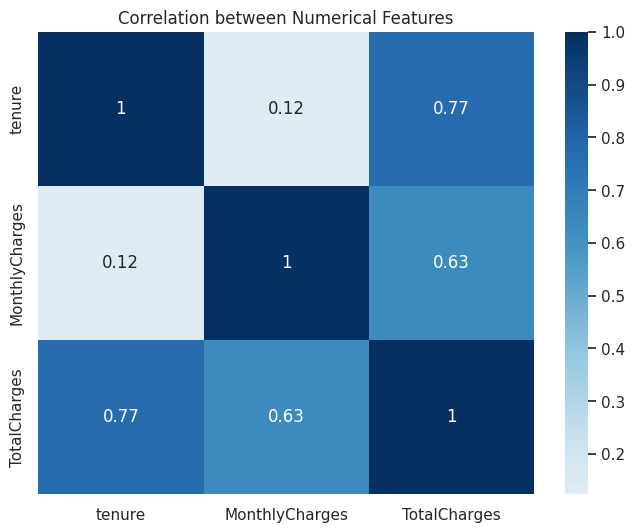

In [ ]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
train[num_features].hist(bins=30, figsize=(15, 5), layout=(1, 3))
plt.suptitle('Distribution of Numerical Features')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(train[num_features].corr(), annot=True, cmap='RdBu', center=0)
plt.title('Correlation between Numerical Features')
plt.show()

In [ ]:
def preprocess_data(df):
    df = df.copy()

    services = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

    df['TotalServicesCount'] = df[services].apply(lambda x: x == 'Yes').sum(axis=1)

    df['AvgCostPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

    return df

train = preprocess_data(train)
test = preprocess_data(test)

cat_cols = train.select_dtypes(include=['object']).columns.tolist()
if 'Churn' in cat_cols: cat_cols.remove('Churn')

for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

In [ ]:
X = train.drop('Churn', axis=1)
y = train['Churn']
X_test = test

In [ ]:
lgb_best_params =  {'learning_rate': 0.023995032558428896, 'num_leaves': 170, 'feature_fraction': 0.5276697332581842, 'bagging_fraction': 0.7642672035206084, 'min_child_samples': 84}
xgb_best_params =  {'learning_rate': 0.04283011196521757, 'n_estimators': 1696, 'max_depth': 4, 'subsample': 0.6191753796286397, 'colsample_bytree': 0.5590770607758936, 'min_child_weight': 16, 'gamma': 0.3827113786416227}
cb_best_params = {'iterations': 1458, 'learning_rate': 0.08414384586331634, 'depth': 5, 'l2_leaf_reg': 7.381344784664483, 'bootstrap_type': 'MVS', 'random_strength': 1.3458319345058636e-05}

In [ ]:
import matplotlib.pyplot as plt

def train_model(model_type, params, X, y, X_test):
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))

    local_params = params.copy()
    local_params.pop('n_estimators', None)
    local_params.pop('iterations', None)

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        if model_type == 'lgbm':
            model = lgb.LGBMClassifier(**local_params, n_estimators=2000, verbosity=-1, metric='auc')
            evals_result = {}
            model.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_va, y_va)],
                      eval_names=['train', 'valid'],
                      callbacks=[lgb.early_stopping(100)])

        elif model_type == 'xgb':
            model = xgb.XGBClassifier(**local_params, n_estimators=2000, tree_method='hist',
                                      early_stopping_rounds=100)
            model.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_va, y_va)], verbose=False)


        elif model_type == 'cat':
            model = cb.CatBoostClassifier(**local_params, iterations=2000, verbose=False,
                                       early_stopping_rounds=100, eval_metric='AUC')
            model.fit(X_tr, y_tr, eval_set=(X_va, y_va))

        oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / 5
        print(f"Model {model_type} Fold {fold+1} | AUC: {roc_auc_score(y_va, oof_preds[val_idx]):.5f}")

    return oof_preds, test_preds

lgb_oof, lgb_test = train_model('lgbm', lgb_best_params, X, y, X_test)
xgb_oof, xgb_test = train_model('xgb', xgb_best_params, X, y, X_test)
cat_oof, cat_test = train_model('cat', cb_best_params, X, y, X_test)

ValueError: Input y contains NaN.

In [ ]:
from scipy.stats import rankdata

# Convert probabilities to ranks
rank_lgb = rankdata(lgb_test)
rank_xgb = rankdata(xgb_test)
rank_cat = rankdata(cat_test)

norm_rank_lgb = rank_lgb / len(rank_lgb)
norm_rank_xgb = rank_xgb / len(rank_xgb)
norm_rank_cat = rank_cat / len(rank_cat)

final_predictions = (0.40 * norm_rank_lgb) + (0.30 * norm_rank_xgb) + (0.30 * norm_rank_cat)

submission = pd.DataFrame({
    'id': test_ids,
    'Churn': final_predictions
})

submission.to_csv('submission.csv', index=False)
print("Final ensemble submission saved!")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

preds_df = pd.DataFrame({
    'LGBM': rank_lgb,
    'XGBoost': rank_xgb,
    'CatBoost': rank_cat,
    'Blend': rankdata(final_predictions)
})

plt.figure(figsize=(8, 6))
sns.heatmap(preds_df.corr(), annot=True, cmap='RdYlGn', fmt='.4f')
plt.title('Correlation Between Base Models and Final Blend')
plt.show()

In [ ]:
sns.pairplot(preds_df.sample(1000),
             diag_kind='kde',
             plot_kws={'alpha': 0.3, 's': 10, 'color': 'purple'})
plt.suptitle('Pairwise Comparison of Model Predictions', y=1.02)
plt.show()

In [ ]:
train.dropna(subset=['Churn'], inplace=True)
X = train.drop('Churn', axis=1)
y = train['Churn']

print(f"New Train Shape: {train.shape}")
print(f"New X Shape: {X.shape}")
print(f"New y Shape: {y.shape}")
print(f"Number of NaNs in 'Churn' column after dropping: {train['Churn'].isnull().sum()}")

New Train Shape: (594194, 22)
New X Shape: (594194, 21)
New y Shape: (594194,)
Number of NaNs in 'Churn' column after dropping: 0


In [ ]:
import matplotlib.pyplot as plt

def train_model(model_type, params, X, y, X_test):
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))

    local_params = params.copy()
    local_params.pop('n_estimators', None)
    local_params.pop('iterations', None)

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        if model_type == 'lgbm':
            model = lgb.LGBMClassifier(**local_params, n_estimators=2000, verbosity=-1, metric='auc')
            evals_result = {}
            model.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_va, y_va)],
                      eval_names=['train', 'valid'],
                      callbacks=[lgb.early_stopping(100)])

        elif model_type == 'xgb':
            model = xgb.XGBClassifier(**local_params, n_estimators=2000, tree_method='hist',
                                      early_stopping_rounds=100)
            model.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_va, y_va)], verbose=False)


        elif model_type == 'cat':
            model = cb.CatBoostClassifier(**local_params, iterations=2000, verbose=False,
                                       early_stopping_rounds=100, eval_metric='AUC')
            model.fit(X_tr, y_tr, eval_set=(X_va, y_va))

        oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / 5
        print(f"Model {model_type} Fold {fold+1} | AUC: {roc_auc_score(y_va, oof_preds[val_idx]):.5f}")

    return oof_preds, test_preds

lgb_oof, lgb_test = train_model('lgbm', lgb_best_params, X, y, X_test)
xgb_oof, xgb_test = train_model('xgb', xgb_best_params, X, y, X_test)
cat_oof, cat_test = train_model('cat', cb_best_params, X, y, X_test)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[603]	train's auc: 0.92721	valid's auc: 0.916092
Model lgbm Fold 1 | AUC: 0.91609
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[621]	train's auc: 0.927274	valid's auc: 0.917204
Model lgbm Fold 2 | AUC: 0.91720
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[642]	train's auc: 0.927767	valid's auc: 0.916488
Model lgbm Fold 3 | AUC: 0.91649
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[516]	train's auc: 0.925552	valid's auc: 0.917497
Model lgbm Fold 4 | AUC: 0.91750
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[496]	train's auc: 0.92601	valid's auc: 0.914757
Model lgbm Fold 5 | AUC: 0.91476
Model xgb Fold 1 | AUC: 0.91646
Model xgb Fold 2 | AUC: 0.91740
Model xgb Fold 3 | AUC: 0.91687
Model 